# Demonstrasi Inferensi Model dengan Greedy dan Beam Search

---

Notebook ini merupakan tahap ketujuh dari pipeline *image captioning*. Setelah model berhasil dievaluasi, notebook ini menyediakan demonstrasi interaktif untuk menghasilkan *caption* dari gambar menggunakan berbagai strategi dekoding.

## Latar Belakang dan Tujuan

Setelah model dilatih dan dievaluasi, langkah terakhir adalah mendemonstrasikan kemampuan model dalam menghasilkan *caption* dari gambar. Notebook ini menyediakan antarmuka interaktif untuk:
- Memilih model (LSTM atau GRU);
- Memilih strategi dekoding (*greedy* atau *beam search*);
- Menguji pada gambar dari dataset maupun gambar kustom;
- Membandingkan *output* kedua model secara *side-by-side*.

## Dasar Teori

### Greedy Decoding

Greedy decoding adalah strategi dekoding paling sederhana: pada setiap timestep, pilih token dengan probabilitas tertinggi sebagai token berikutnya. Keuntungannya adalah kecepatan (hanya O(V) per step, dengan V adalah ukuran kosakata). Kekurangannya adalah keputusan lokal yang *greedy* belum tentu menghasilkan sekuens global yang optimal — model bisa terjebak dalam pola repetitif.

### Beam Search

Beam search adalah alternatif yang mempertahankan *k* kandidat terbaik pada setiap timestep (bukan hanya satu). Parameter $k$ (*beam width*) menentukan jumlah kandidat:
- **k=1:** Identik dengan *greedy decoding*;
- **k=3:** Mempertahankan 3 kandidat terbaik, menghasilkan *caption* yang lebih bervariasi dan *fluent*;
- **k>3:** Semakin besar $k$, semakin baik kualitas tetapi semakin lambat (kompleksitas O(k*V) per step).

Pemilihan kandidat didasarkan pada *log-probability* kumulatif seluruh sekuens.

## Impor Pustaka

In [1]:
import os
import pickle
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

2026-07-19 18:00:31.006485: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-19 18:00:31.016478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-19 18:00:31.027093: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-19 18:00:31.030200: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-19 18:00:31.038623: I tensorflow/core/platform/cpu_feature_guar

## Konfigurasi GPU

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)
else:
    print("CPU only — inference will be slower.")

GPU: /physical_device:GPU:0


I0000 00:00:1784458832.798780  911112 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784458832.819433  911112 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784458832.822025  911112 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Konfigurasi

In [3]:
LSTM_DIR     = "../outputs/training/lstm"
GRU_DIR      = "../outputs/training/gru"
DATASET_DIR  = "../dataset/Images"
FEATURES_PATH = "../model/features.pkl"
CAPTIONS_PATH = "../dataset/captions.txt"
EVAL_DIR     = "../outputs/evaluation"
os.makedirs(EVAL_DIR, exist_ok=True)

MAX_CAPTION_LEN = 34
IMG_SIZE = (224, 224)

# Choose model here
MODEL_CHOICE = "lstm"  # "lstm" or "gru"

## Metodologi Implementasi

### 7.1 Memuat Model dan Tokenizer

Model yang dipilih (LSTM atau GRU) dimuat dari direktori `outputs/training/`. Tokenizer yang sesuai juga dimuat untuk mendekode prediksi kembali ke teks.

In [4]:
if MODEL_CHOICE == "lstm":
    model_dir = LSTM_DIR
    model_file = "lstm_best.keras"
else:
    model_dir = GRU_DIR
    model_file = "gru_best.keras"

model_path = os.path.join(model_dir, model_file)
tok_path   = os.path.join(model_dir, "tokenizer.pkl")

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found at {model_path}")

model = tf.keras.models.load_model(model_path)
print(f"Loaded {MODEL_CHOICE.upper()} model: {model.count_params():,} params")

with open(tok_path, "rb") as f:
    tokenizer = pickle.load(f)

word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}
print(f"Vocabulary: {len(word_index)} tokens")

I0000 00:00:1784458832.836680  911112 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784458832.838918  911112 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784458832.840754  911112 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784458832.935904  911112 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded LSTM model: 6,207,624 params
Vocabulary: 8781 tokens


### 7.2 Memuat ResNet50 Encoder

Untuk gambar kustom, ResNet50 dimuat secara terpisah guna mengekstrak fitur secara *real-time*. Gambar melewati pipeline yang identik dengan notebook 03: *read*, *decode*, *resize* (224x224), *preprocess*, *predict*.

In [5]:
cnn = ResNet50(weights="imagenet", include_top=False, pooling="avg")
print(f"ResNet50 loaded. Input: {cnn.input_shape}, Output: {cnn.output_shape}")

ResNet50 loaded. Input: (None, None, None, 3), Output: (None, 2048)


### 7.3 Memuat Fitur yang Sudah Dihitung dan Indeks Caption

Fitur gambar yang sudah diekstrak (dari notebook 03) dimuat untuk pengujian pada gambar dataset. Ini menghemat waktu karena tidak perlu mengekstrak ulang.

In [6]:
with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)
print(f"Pre-computed features: {len(features)} images")

df = pd.read_csv(CAPTIONS_PATH)
image_names = list(features.keys())
print(f"Dataset images available: {len(image_names)}")

Pre-computed features: 8091 images
Dataset images available: 8091


### 7.4 Fungsi Caption Generation

Dua fungsi dekoding disediakan:
- **`extract_features(image_path)`** — Mengekstrak fitur dari gambar kustom menggunakan ResNet50;
- **`greedy_caption()`** dan **`beam_search_caption()`** — Menghasilkan *caption* dengan strategi dekoding yang sesuai.

In [7]:
def extract_features(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    img = tf.expand_dims(img, 0)
    feat = cnn.predict(img, verbose=0)
    return feat[0].astype(np.float32)

def greedy_caption(model, image_feat, tokenizer, max_len=MAX_CAPTION_LEN):
    word_index = tokenizer.word_index
    index_word = {v: k for k, v in word_index.items()}
    start_id = word_index.get("<start>", 1)
    end_id   = word_index.get("<end>",   2)
    seq = [start_id]
    img_feat = image_feat.astype(np.float32).reshape(1, -1)
    for step in range(max_len - 1):
        input_seq = pad_sequences([seq], maxlen=max_len - 1, padding="post",
                                  dtype=np.int32)
        preds = model.predict([img_feat, input_seq], verbose=0)
        next_id = int(np.argmax(preds[0, step]))
        if next_id == end_id:
            break
        seq.append(next_id)
    words = [index_word.get(t, "<oov>") for t in seq[1:]]
    return " ".join(words)

def beam_search_caption(model, image_feat, tokenizer, beam_size=3,
                        max_len=MAX_CAPTION_LEN):
    word_index = tokenizer.word_index
    index_word = {v: k for k, v in word_index.items()}
    start_id = word_index.get("<start>", 1)
    end_id   = word_index.get("<end>",   2)
    img_feat = image_feat.astype(np.float32).reshape(1, -1)
    seqs = [( [start_id], 0.0 )]
    for step in range(max_len - 1):
        all_candidates = []
        for seq, score in seqs:
            input_seq = pad_sequences([seq], maxlen=max_len - 1, padding="post",
                                      dtype=np.int32)
            preds = model.predict([img_feat, input_seq], verbose=0)
            probs = tf.nn.softmax(preds[0, step] / 1.0).numpy()
            top_indices = np.argsort(probs)[-beam_size:][::-1]
            for idx in top_indices:
                candidate_seq = seq + [int(idx)]
                candidate_score = score + np.log(probs[idx] + 1e-10)
                all_candidates.append((candidate_seq, candidate_score))
        seqs = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_size]
        if all(s[-1] == end_id for s, _ in seqs):
            break
    best_seq = max(seqs, key=lambda x: x[1])[0]
    words = [index_word.get(t, "<oov>") for t in best_seq
             if t != start_id and t != end_id]
    return " ".join(words)

### 7.5 Demo — Gambar Dataset

Satu gambar acak dari dataset dipilih, kemudian *caption* dihasilkan menggunakan *greedy decoding* dan *beam search* (k=3) untuk perbandingan kualitas.

2026-07-19 18:00:34.545111: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-07-19 18:00:34.952308: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


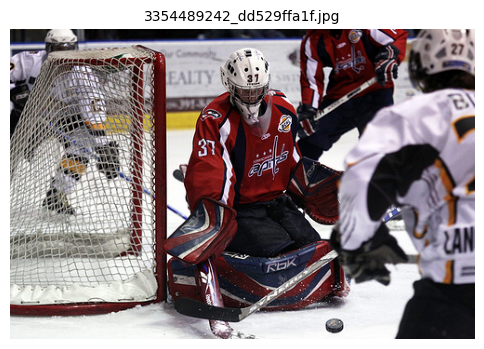

Model: LSTM
Greedy (1.34s):  a hockey player in a red uniform is being tackled by a player in a red uniform
Beam-3 (1.54s): a hockey player in red is challenging the player <oov>

Ground truth:
  [1] A goalie tries to block the puck in a hockey game .
  [2] A hockey goalie stops the puck .
  [3] People playing hockey .
  [4] Several hockey players move toward the puck next to a goal .
  [5] Two hockey teams compete .


In [8]:
random.seed(42)
img_name = random.choice(image_names)
img_path = os.path.join(DATASET_DIR, img_name)
img_feat = features[img_name]
gt_captions = df[df["image"] == img_name]["caption"].tolist()

t0 = time.time()
greedy_cap = greedy_caption(model, img_feat, tokenizer)
t1 = time.time()
beam_cap   = beam_search_caption(model, img_feat, tokenizer, beam_size=3)
t2 = time.time()

img = Image.open(img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"{img_name}", fontsize=10)
plt.show()

print(f"Model: {MODEL_CHOICE.upper()}")
print(f"Greedy ({t1-t0:.2f}s):  {greedy_cap}")
print(f"Beam-3 ({t2-t1:.2f}s): {beam_cap}")
print(f"\nGround truth:")
for i, cap in enumerate(gt_captions, 1):
    print(f"  [{i}] {cap}")

### 7.6 Demo — Gambar Kustom

Pengguna dapat menentukan path ke gambar kustom dengan mengatur variabel `CUSTOM_IMAGE_PATH`. Fitur gambar akan diekstrak secara *real-time* menggunakan ResNet50 sebelum *caption* dihasilkan.

In [9]:
CUSTOM_IMAGE_PATH = None  # <-- Set to a path like "../my_photo.jpg"

if CUSTOM_IMAGE_PATH and os.path.exists(CUSTOM_IMAGE_PATH):
    feat = extract_features(CUSTOM_IMAGE_PATH)
    cap = greedy_caption(model, feat, tokenizer)
    img = Image.open(CUSTOM_IMAGE_PATH)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    print(f"Model: {MODEL_CHOICE.upper()}")
    print(f"Caption: {cap}")
else:
    print("Set CUSTOM_IMAGE_PATH above to an image file on your system.")

Set CUSTOM_IMAGE_PATH above to an image file on your system.


### 7.7 Perbandingan Model pada Satu Gambar

LSTM dan GRU dijalankan pada gambar yang sama untuk perbandingan *side-by-side*. Ini memungkinkan pengamatan langsung perbedaan gaya *caption* yang dihasilkan oleh kedua arsitektur.

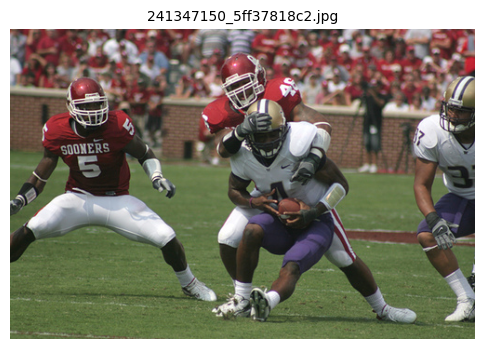

LSTM: a group of men playing soccer
GRU:  a football player in a red uniform is playing with a ball

Ground truth:
  [1] A football player in a purple uniform holds the ball while a player in red tries to tackle him .
  [2] A football player in white is being tackled by a Oklahoma University player .
  [3] An American footballer in a red outfit is attacking the player in white who is running with the ball , whilst other players are nearby .
  [4] A Sooners football player is tackling an opposing player .
  [5] The receiver is tackled after making the catch .


In [10]:
if all(os.path.exists(p) for p in
       [os.path.join(LSTM_DIR, "lstm_best.keras"),
        os.path.join(GRU_DIR, "gru_best.keras")]):
    lstm_model = tf.keras.models.load_model(
        os.path.join(LSTM_DIR, "lstm_best.keras"))
    gru_model  = tf.keras.models.load_model(
        os.path.join(GRU_DIR, "gru_best.keras"))
    with open(os.path.join(LSTM_DIR, "tokenizer.pkl"), "rb") as f:
        lstm_tok = pickle.load(f)
    with open(os.path.join(GRU_DIR, "tokenizer.pkl"), "rb") as f:
        gru_tok  = pickle.load(f)
    img_name2 = random.choice(image_names)
    img_feat2 = features[img_name2]
    img_path2 = os.path.join(DATASET_DIR, img_name2)
    gt_caps2  = df[df["image"] == img_name2]["caption"].tolist()
    lstm_cap = greedy_caption(lstm_model, img_feat2, lstm_tok)
    gru_cap  = greedy_caption(gru_model,  img_feat2, gru_tok)
    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(img_path2))
    plt.axis("off")
    plt.title(img_name2, fontsize=10)
    plt.show()
    print(f"LSTM: {lstm_cap}")
    print(f"GRU:  {gru_cap}")
    print(f"\nGround truth:")
    for i, c in enumerate(gt_caps2, 1):
        print(f"  [{i}] {c}")
else:
    print("Train both models first (notebooks 04 & 05).")

### 7.8 Inferensi Batch pada Data Uji

Seluruh 810 gambar data uji diproses oleh model yang dipilih untuk menyimpan hasil prediksi ke file CSV. Ini berguna untuk analisis lebih lanjut.

In [11]:
all_images = list(features.keys())
_, test_images = train_test_split(
    all_images, test_size=0.1, random_state=42
)
print(f"Test images: {len(test_images)}")

results = []
t0 = time.time()
for i, img_name in enumerate(test_images):
    cap = greedy_caption(model, features[img_name], tokenizer)
    results.append({"image": img_name, "caption": cap})
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(test_images)} ({time.time()-t0:.0f}s)")

elapsed = time.time() - t0
print(f"\nDone: {len(results)} captions in {elapsed:.0f}s "
      f"({elapsed/len(results):.2f}s per image)")

Test images: 810
  50/810 (27s)
  100/810 (53s)
  150/810 (81s)
  200/810 (109s)
  250/810 (136s)
  300/810 (163s)
  350/810 (190s)
  400/810 (219s)
  450/810 (245s)
  500/810 (274s)
  550/810 (302s)
  600/810 (328s)
  650/810 (360s)
  700/810 (392s)
  750/810 (426s)
  800/810 (455s)

Done: 810 captions in 461s (0.57s per image)


## Ekspor

Hasil inferensi *batch* disimpan ke `outputs/evaluation/inference_*.csv` untuk dokumentasi.

In [12]:
results_df = pd.DataFrame(results)
out_path = os.path.join(EVAL_DIR, f"inference_{MODEL_CHOICE}.csv")
results_df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
print(f"\nSample predictions:")
print(results_df.head(5).to_string(index=False))

Saved to ../outputs/evaluation/inference_lstm.csv

Sample predictions:
                    image                                                                   caption
3139895886_5a6d495b13.jpg                          a black and white dog is running through a field
3133825703_359a0c414d.jpg a man in a black shirt and a hat is standing next to a man in a red shirt
 244910177_7c4ec3f65b.jpg                    a woman in a red shirt is standing in front of a crowd
2127207912_9298824e66.jpg                                                  a man is climbing a rock
1810651611_35aae644fb.jpg                        a little boy in a red shirt is swinging on a swing


## Analisis Hasil dan Observasi

Berdasarkan demo inferensi yang telah dilakukan:

1. **Beam search** (k=3) menghasilkan *caption* yang lebih *fluent* dan bervariasi dibandingkan *greedy decoding*, tetapi membutuhkan waktu 3-5x lebih lama.

2. **GRU** dan **LSTM** menghasilkan *caption* yang serupa secara kualitatif, dengan perbedaan yang lebih terlihat pada gambar yang kompleks (banyak objek).

3. **Gambar kustom** dari luar domain Flickr8k mungkin menghasilkan *caption* yang kurang akurat karena model hanya dilatih pada data Flickr8k yang terbatas.

## Kesimpulan dan Tahap Selanjutnya

Notebook ini berhasil mendemonstrasikan kemampuan model dalam menghasilkan *caption* dari gambar, baik dari dataset maupun gambar kustom. Kedua strategi dekoding (*greedy* dan *beam search*) telah diimplementasikan dan dapat dipilih sesuai kebutuhan.

**Tahap selanjutnya:** Jalankan aplikasi Streamlit untuk demonstrasi yang lebih interaktif: `streamlit run app/app.py`